In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform

In [2]:
#0 = cloudy
#1 = clear

In [9]:
N = 100000
states = np.zeros(N, dtype = int)

In [10]:
#initial state: cloudy
states[0] = 0

In [11]:
rng = np.random.default_rng()

In [12]:
for t in range(1, N):
    r = rng.random()

    if states[t-1] == 0: #today is cloudy
        if r < 0.5:
            states[t] = 1 #tomorrow is clear
        else:
            states[t] = 0 #tomorrow is cloudy
    else: #tomorrow is clear
        if r<0.9:
            states[t] = 1 #tomorrow is clear
        else:
            states[t] = 0 #tomorrow is cloudy

In [13]:
clear_days = (states == 1).astype(int)
cum_clear = np.cumsum(clear_days)
days = np.arange(1, N+1)
trace = cum_clear/days

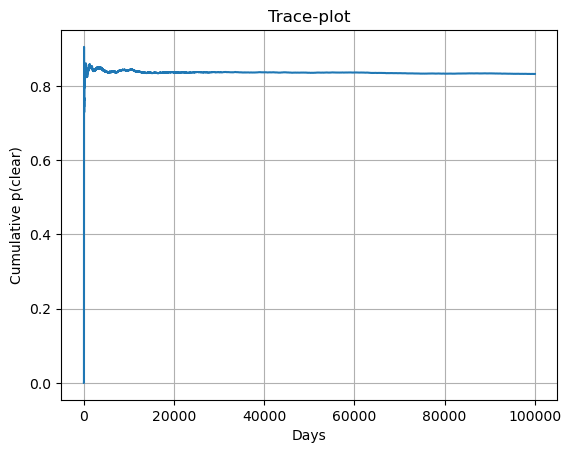

In [14]:
plt.figure()
plt.plot(days, trace)
plt.xlabel("Days")
plt.ylabel("Cumulative p(clear)")
plt.title("Trace-plot")
plt.grid()
plt.show()

In [19]:
mean = np.mean(samples)
std = np.std(samples)
median = np.median(samples)
print(median, mean, std)

0.8356149110445376 0.8355174249709711 0.0026451006552655827


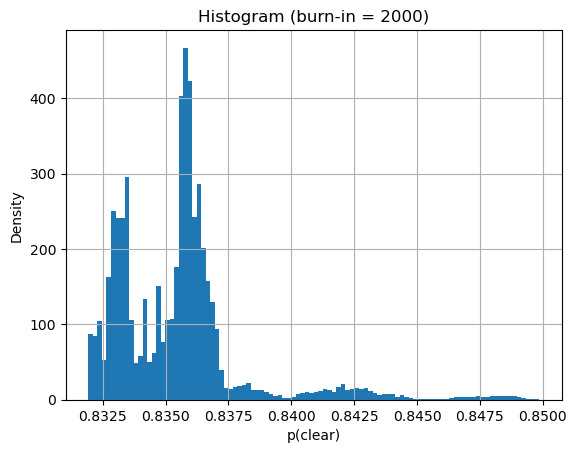

In [18]:
burn_in = 2000
samples = trace[burn_in:]

plt.figure()
plt.hist(samples, bins=100, density=True)
plt.xlabel("p(clear)")
plt.ylabel("Density")
plt.title(f"Histogram (burn-in = {burn_in})")
plt.grid()
plt.show()

In [21]:
#for different burn-ins:
for b in [0, 100, 1000, 5000]:
    print(b, np.mean(trace[b:]))

0 0.835609552212114
100 0.8356793317548777
1000 0.8356603533634311
5000 0.8352376095379224
